#### Regression Modeling

In this script, we explore a few different types of regression models to predict a player's market value based on their performance

Options include: linear regression, random forest, XGBoost, CatBoost 

In [1]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

In [2]:
#Load cleaned data
final_data = pd.read_csv('final_data.csv')

#### Feature Engineering

In [3]:
#Aggregation logic to consolidate multiple entries per season (in case of mid-season transfer)
agg_dict = {
    'market_value_in_eur': 'first',
    'starts': 'sum',
    'subs': 'sum',
    'captains': 'sum',
    'total_minutes': 'sum',
    'total_yellow_cards': 'sum',
    'total_red_cards': 'sum',
    'total_goals': 'sum',
    'total_assists': 'sum',
    'club_name': 'last',
    'league': 'last',
    'name': 'first',
    'position': 'first',
    'foot': 'first',
    'age': 'first'
}

# Group and aggregate
final_data_agg = final_data.groupby(['player_id', 'season']).agg(agg_dict).reset_index()

#Feature for prior season's market value
final_data_agg = final_data_agg.sort_values(by=['player_id', 'season'])
final_data_agg['last_season_market_value'] = final_data_agg.groupby('player_id')['market_value_in_eur'].shift(1)

#Feature engineering on 'starts' column
#Prevents high collinearity between 'starts' and 'total_minutes'
final_data_agg['starts_prop'] = final_data_agg['starts'] / (final_data_agg['starts'] + final_data_agg['subs'])

#Create binary feature for big five league vs. others
big_five_leagues = ['Premier League', 'Serie A', 'Ligue 1', 'Bundesliga', 'La Liga']
final_data_agg['big_five_league'] = np.where(final_data_agg['league'].isin(big_five_leagues), 1, 0)

final_data_agg.head()


,player_id,season,market_value_in_eur,starts,subs,captains,total_minutes,total_yellow_cards,total_red_cards,total_goals,total_assists,club_name,league,name,position,foot,age,last_season_market_value,starts_prop,big_five_league
0,10,2013/2014,1000000.0,24,8,0,2220,2,0,8,5,Società Sportiva Lazio S.p.A.,Serie A,Miroslav Klose,Attack,right,35.0,NaN,0.750000,1
1,10,2014/2015,1000000.0,26,17,0,2289,6,0,16,9,Società Sportiva Lazio S.p.A.,Serie A,Miroslav Klose,Attack,right,36.0,1000000.0,0.604651,1
2,10,2015/2016,1000000.0,19,20,5,1714,3,0,8,8,Società Sportiva Lazio S.p.A.,Serie A,Miroslav Klose,Attack,right,37.0,1000000.0,0.487179,1
3,26,2012/2013,4500000.0,1,0,1,4491,2,1,0,0,Borussia Dortmund,Bundesliga,Roman Weidenfeller,Goalkeeper,left,32.0,NaN,1.000000,1
4,26,2013/2014,5000000.0,42,4,24,3765,1,1,0,0,Borussia Dortmund,Bundesliga,Roman Weidenfeller,Goalkeeper,left,33.0,4500000.0,0.913043,1


In [4]:
#Attempting winsorisation to reduce variability without removing data points

#Trim/cap market value (top and bottom 10%)
p_lower = final_data_agg['market_value_in_eur'].quantile(0.1)
p_upper = final_data_agg['market_value_in_eur'].quantile(0.9)

final_data_agg['market_value_capped'] = final_data_agg['market_value_in_eur'].clip(lower=p_lower, upper=p_upper)
final_data_agg['market_value_capped'].mean()

#Trim/cap prior season's market value (top and bottom 10%)
p_lower_2 = final_data_agg['last_season_market_value'].quantile(0.1)
p_upper_2 = final_data_agg['last_season_market_value'].quantile(0.9)

final_data_agg['last_season_market_value_capped'] = final_data_agg['last_season_market_value'].clip(lower=p_lower_2, upper=p_upper_2)
final_data_agg['last_season_market_value_capped'].mean()

#Create change in market value feature (fill NA with zero for players with only one season)
final_data_agg['market_value_change'] = final_data_agg['market_value_capped'] - final_data_agg['last_season_market_value_capped']
final_data_agg['market_value_change'] = final_data_agg['market_value_change'].fillna(0)

#TEST: log transform market value to see if it improves performance
final_data_agg['market_value_log'] = np.log1p(final_data_agg['market_value_in_eur'])

In [5]:
final_data_agg.head()

,player_id,season,market_value_in_eur,starts,subs,captains,total_minutes,total_yellow_cards,total_red_cards,total_goals,...,position,foot,age,last_season_market_value,starts_prop,big_five_league,market_value_capped,last_season_market_value_capped,market_value_change,market_value_log
0,10,2013/2014,1000000.0,24,8,0,2220,2,0,8,...,Attack,right,35.0,NaN,0.750000,1,1000000.0,NaN,0.0,13.815512
1,10,2014/2015,1000000.0,26,17,0,2289,6,0,16,...,Attack,right,36.0,1000000.0,0.604651,1,1000000.0,1000000.0,0.0,13.815512
2,10,2015/2016,1000000.0,19,20,5,1714,3,0,8,...,Attack,right,37.0,1000000.0,0.487179,1,1000000.0,1000000.0,0.0,13.815512
3,26,2012/2013,4500000.0,1,0,1,4491,2,1,0,...,Goalkeeper,left,32.0,NaN,1.000000,1,4500000.0,NaN,0.0,15.319588
4,26,2013/2014,5000000.0,42,4,24,3765,1,1,0,...,Goalkeeper,left,33.0,4500000.0,0.913043,1,5000000.0,4500000.0,500000.0,15.424949


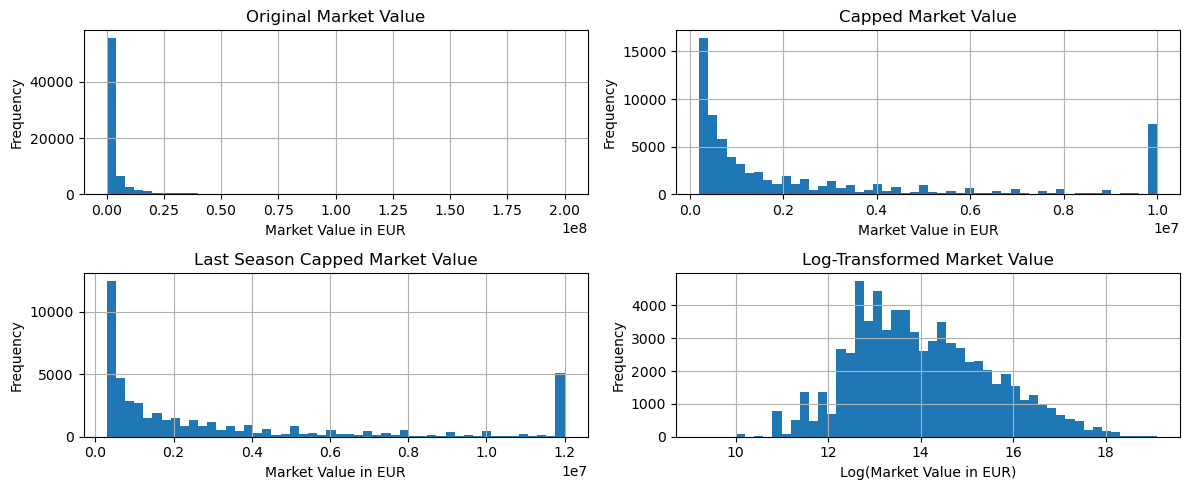

In [6]:
#Create plots to compare original column to transformations done above

fig, axes = plt.subplots(2, 2, figsize=(12, 5))

final_data_agg['market_value_in_eur'].hist(ax=axes[0,0], bins=50)
axes[0,0].set_title('Original Market Value')
axes[0,0].set_xlabel('Market Value in EUR')
axes[0,0].set_ylabel('Frequency')

final_data_agg['market_value_capped'].hist(ax=axes[0,1], bins=50)
axes[0,1].set_title('Capped Market Value')
axes[0,1].set_xlabel('Market Value in EUR')
axes[0,1].set_ylabel('Frequency')

final_data_agg['last_season_market_value_capped'].hist(ax=axes[1,0], bins=50)
axes[1,0].set_title('Last Season Capped Market Value')
axes[1,0].set_xlabel('Market Value in EUR')
axes[1,0].set_ylabel('Frequency')

final_data_agg['market_value_log'].hist(ax=axes[1,1], bins=50)
axes[1,1].set_title('Log-Transformed Market Value')
axes[1,1].set_xlabel('Log(Market Value in EUR)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [7]:
#Divide data into target and (potential) features
y = final_data_agg['market_value_capped']
X = final_data_agg[['captains', 'total_minutes', 'total_yellow_cards', 'total_red_cards','total_goals', 'total_assists', 
        'league', 'position', 'foot', 'age', 'last_season_market_value_capped', 'starts_prop', 'big_five_league']]

#Before model building, create training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

#### Linear Regression Model

Determined this is not the best approach

Even after transformation, the model cannot capture the variation in market value/complex relationships between features and residual assumptions are not met 


In [8]:
#Dummy encoding of categorical features (drop one level for no multicollinearity)
X_train_encoded = pd.get_dummies(X_train, columns=['position', 'league', 'foot'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['position', 'league', 'foot'], drop_first=True)

#Ensures the columns in the test data match those in training 
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)


In [9]:
X_train_encoded.columns

Index(['captains', 'total_minutes', 'total_yellow_cards', 'total_red_cards',
       'total_goals', 'total_assists', 'age',
       'last_season_market_value_capped', 'starts_prop', 'big_five_league',
       'position_Defender', 'position_Goalkeeper', 'position_Midfield',
       'league_Bundesliga', 'league_Danish Superliga', 'league_Eredivisie',
       'league_La Liga', 'league_Ligue 1', 'league_Premier League',
       'league_Primeira Liga', 'league_Russian Premier League',
       'league_Scottish Premiership', 'league_Serie A',
       'league_Super League Greece', 'league_Super Lig',
       'league_Ukrainian Premier League', 'foot_left', 'foot_right'],
      dtype='object')

In [10]:
#Select features for model
X_train_lr = X_train_encoded[['age', 'starts_prop', 'captains', 'total_minutes', 'total_yellow_cards',
       'total_red_cards', 'total_goals', 'total_assists', 'big_five_league',
       'position_Defender', 'position_Goalkeeper', 'position_Midfield']]

X_test_lr = X_test_encoded[['age', 'starts_prop', 'captains', 'total_minutes', 'total_yellow_cards',
       'total_red_cards', 'total_goals', 'total_assists', 'big_five_league',
       'position_Defender', 'position_Goalkeeper', 'position_Midfield']]

#Build linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_lr, np.log(y_train))

#Make predictions (for in/out of sample performance)
lr_pred_test = lr_model.predict(X_test_lr)
lr_pred_train = lr_model.predict(X_train_lr)

#Convert predictions back to original scale
lr_pred_test_final = np.expm1(lr_pred_test)
lr_pred_train_final = np.expm1(lr_pred_train)

#Calculate and report accuracy metrics
n = len(y_test)
k = X_test_lr.shape[1]
r2 = r2_score(y_test, lr_pred_test_final)
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
rmse_test = np.sqrt(mean_squared_error(y_test, lr_pred_test_final))
rmse_train = np.sqrt(mean_squared_error(y_train, lr_pred_train_final))

#print(f"R-squared: {r2:.4f}")
#print(f"Adjusted R-squared: {adj_r2:.4f}")
print(f"In-Sample RMSE: {rmse_train:.4f}")
print(f"Out-of-Sample RMSE: {rmse_test:.4f}")

In-Sample RMSE: 3648232.8497
Out-of-Sample RMSE: 2804077.9437


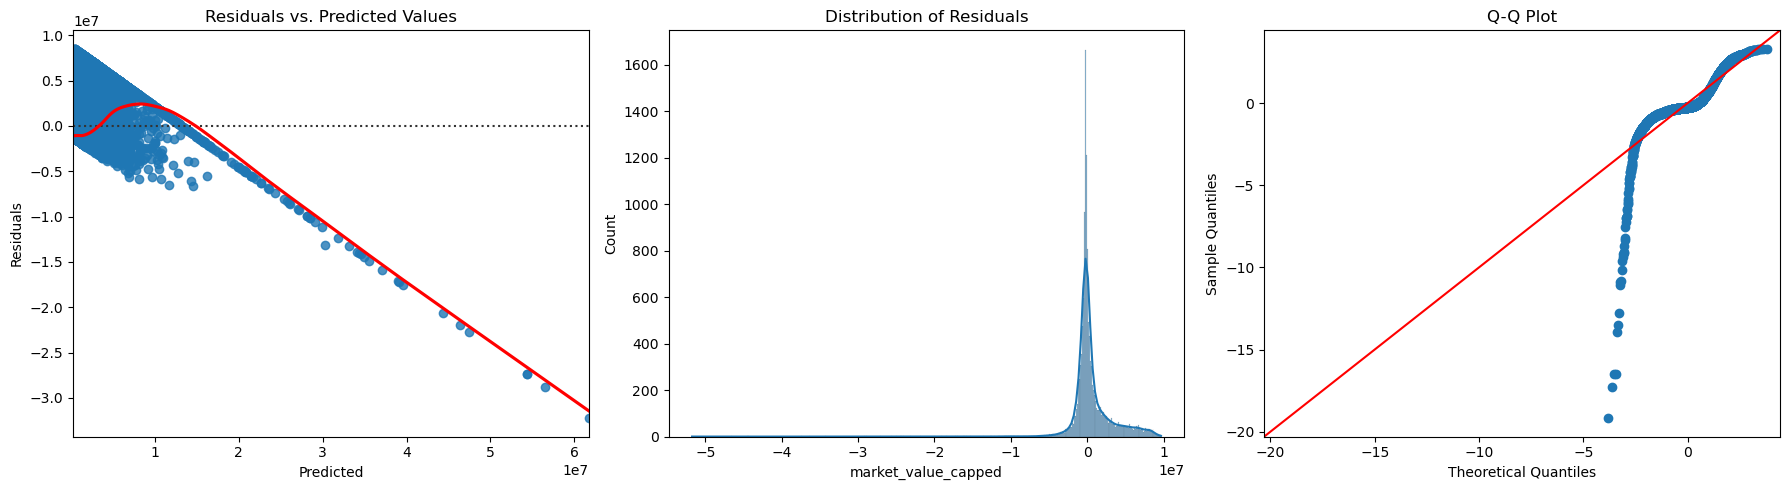

In [11]:
#Calculate residuals for analysis
residuals = y_test - lr_pred_test_final

#Examine residual plots
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

#Plot 1: Residual Plot
sns.residplot(x=lr_pred_test_final, y=y_test, 
              lowess=True, ax=ax[0], line_kws={'color': 'red'})
ax[0].set_title('Residuals vs. Predicted Values')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Residuals')

#Plot 2: Histogram
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title('Distribution of Residuals')

#Plot 3: Q-Q Plot
sm.qqplot(residuals, fit=True, line='45', ax=ax[2])
ax[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

#### Random Forest Model

Significant improvement from LR

Other models still outperformed it, but need to consider computation time and interpretability

In [16]:
#Select features for model
X_train_rf = X_train_encoded[['total_minutes', 'captains',
       'total_goals', 'total_assists', 'age',
       'last_season_market_value_capped', 'starts_prop',
       'league_Bundesliga', 'league_Danish Superliga', 'league_Eredivisie',
       'league_La Liga', 'league_Ligue 1', 'league_Premier League',
       'league_Primeira Liga', 'league_Russian Premier League',
       'league_Scottish Premiership', 'league_Serie A',
       'league_Super League Greece', 'league_Super Lig',
       'league_Ukrainian Premier League',
       'position_Defender', 'position_Goalkeeper', 'position_Midfield']]

X_test_rf = X_test_encoded[['total_minutes', 'captains',
       'total_goals', 'total_assists', 'age',
       'last_season_market_value_capped', 'starts_prop',
       'league_Bundesliga', 'league_Danish Superliga', 'league_Eredivisie',
       'league_La Liga', 'league_Ligue 1', 'league_Premier League',
       'league_Primeira Liga', 'league_Russian Premier League',
       'league_Scottish Premiership', 'league_Serie A',
       'league_Super League Greece', 'league_Super Lig',
       'league_Ukrainian Premier League',
       'position_Defender', 'position_Goalkeeper', 'position_Midfield']]

#Build Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, max_features="sqrt")
rf_model.fit(X_train_rf, y_train)

#Make predictions (for in/out of sample performance)
rf_pred_train = rf_model.predict(X_train_rf)
rf_pred_test = rf_model.predict(X_test_rf)

#Calculate and report RMSE
rf_rmse_train = np.sqrt(mean_squared_error(y_train, rf_pred_train))
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_pred_test))
print(f"In-Sample RMSE: {rf_rmse_train:.4f}")
print(f"Out-of-Sample RMSE: {rf_rmse_test:.4f}")

#Calculate feature importances (from training data)
feature_importances = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importances)


In-Sample RMSE: 1422218.8581
Out-of-Sample RMSE: 1472960.5105
                            Feature  Importance
5   last_season_market_value_capped    0.551297
0                     total_minutes    0.120626
12            league_Premier League    0.071927
2                       total_goals    0.058211
3                     total_assists    0.056452
4                               age    0.035148
6                       starts_prop    0.028597
16                   league_Serie A    0.015585
10                   league_La Liga    0.012482
7                 league_Bundesliga    0.011238
15      league_Scottish Premiership    0.008073
17       league_Super League Greece    0.007658
8           league_Danish Superliga    0.005287
11                   league_Ligue 1    0.005144
1                          captains    0.003117
9                 league_Eredivisie    0.002241
18                 league_Super Lig    0.001887
19  league_Ukrainian Premier League    0.001401
20                position

In [17]:
#Calculate permutation importance (from test data)
rf_result = permutation_importance(rf_model, X_test_rf, y_test, n_repeats=10, n_jobs=-1)
rf_perm_sorted_idx = rf_result.importances_mean.argsort()
rf_perm_importances = pd.DataFrame(
    rf_result.importances[rf_perm_sorted_idx].T,
    columns=X_test_rf.columns[rf_perm_sorted_idx],
)
print(rf_perm_importances)

   position_Defender  position_Midfield  position_Goalkeeper  \
0          -0.000056           0.000022             0.000230   
1          -0.000043           0.000361             0.000212   
2          -0.000024           0.000190             0.000233   
3           0.000094           0.000246             0.000164   
4          -0.000203           0.000023             0.000255   
5          -0.000029           0.000076             0.000161   
6          -0.000214           0.000053             0.000147   
7          -0.000225           0.000245             0.000137   
8          -0.000186           0.000236             0.000203   
9          -0.000115           0.000253             0.000229   

   league_Primeira Liga  league_Russian Premier League  captains  \
0              0.000264                       0.000237  0.000590   
1              0.000234                       0.000249  0.000734   
2              0.000174                       0.000235  0.000580   
3              0.000220

#### XGBoost Model

Results are better than those of RF, but a little harder to explain


In [15]:
#Select features for model
X_train_xgb = X_train_encoded[['total_minutes', 'captains',
       'total_goals', 'total_assists', 'age',
       'last_season_market_value_capped', 'starts_prop',
       'league_Bundesliga', 'league_Danish Superliga', 'league_Eredivisie',
       'league_La Liga', 'league_Ligue 1', 'league_Premier League',
       'league_Primeira Liga', 'league_Russian Premier League',
       'league_Scottish Premiership', 'league_Serie A',
       'league_Super League Greece', 'league_Super Lig',
       'league_Ukrainian Premier League',
       'position_Defender', 'position_Goalkeeper', 'position_Midfield']]

X_test_xgb = X_test_encoded[['total_minutes', 'captains',
       'total_goals', 'total_assists', 'age',
       'last_season_market_value_capped', 'starts_prop',
       'league_Bundesliga', 'league_Danish Superliga', 'league_Eredivisie',
       'league_La Liga', 'league_Ligue 1', 'league_Premier League',
       'league_Primeira Liga', 'league_Russian Premier League',
       'league_Scottish Premiership', 'league_Serie A',
       'league_Super League Greece', 'league_Super Lig',
       'league_Ukrainian Premier League',
       'position_Defender', 'position_Goalkeeper', 'position_Midfield']]


#Build XGBoost model
xgboost_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, subsample = 0.9)
xgboost_model.fit(X_train_xgb, y_train)

#Make predictions (for in/out of sample performance)
xgboost_pred_train = xgboost_model.predict(X_train_xgb)
xgboost_pred_test = xgboost_model.predict(X_test_xgb)

#Calculate and RMSE
xgb_rmse_train = np.sqrt(mean_squared_error(y_train, xgboost_pred_train))
xgb_rmse_test = np.sqrt(mean_squared_error(y_test, xgboost_pred_test))
print(f"In-Sample RMSE: {xgb_rmse_train:.4f}")
print(f"Out-of-Sample RMSE: {xgb_rmse_test:.4f}")

#Calculate feature importances (from training data)
xgb_importance = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': xgboost_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(xgb_importance)

In-Sample RMSE: 1214996.3795
Out-of-Sample RMSE: 1306184.1043
                            Feature  Importance
5   last_season_market_value_capped    0.430389
12            league_Premier League    0.110810
15      league_Scottish Premiership    0.058577
10                   league_La Liga    0.039854
7                 league_Bundesliga    0.038872
16                   league_Serie A    0.038108
4                               age    0.037841
0                     total_minutes    0.035992
17       league_Super League Greece    0.028993
11                   league_Ligue 1    0.028704
8           league_Danish Superliga    0.026473
9                 league_Eredivisie    0.025232
3                     total_assists    0.023524
2                       total_goals    0.022794
18                 league_Super Lig    0.008597
6                       starts_prop    0.008052
14    league_Russian Premier League    0.008031
19  league_Ukrainian Premier League    0.006543
13             league_Prim

In [18]:
#Calculate permutation importance (from test data)
xgb_result = permutation_importance(xgboost_model, X_test_xgb, y_test, n_repeats=5, n_jobs=-1)
xgb_perm_sorted_idx = xgb_result.importances_mean.argsort()
xgb_perm_importances = pd.DataFrame(
    xgb_result.importances[xgb_perm_sorted_idx].T,
    columns=X_test_xgb.columns[xgb_perm_sorted_idx],
)
print(xgb_perm_importances)

   position_Goalkeeper  league_Primeira Liga  league_Super Lig  \
0             0.000210              0.000813          0.000313   
1             0.000446              0.000410          0.000543   
2             0.000647              0.000802          0.000492   
3             0.000481              0.000171          0.000637   
4             0.000472              0.000214          0.000636   

   position_Midfield  position_Defender  league_Ukrainian Premier League  \
0           0.000923           0.000650                         0.000660   
1           0.000424           0.000896                         0.000915   
2           0.001028           0.000670                         0.000817   
3           0.000636           0.000602                         0.000641   
4           0.000530           0.000733                         0.000818   

   league_Russian Premier League  league_Eredivisie  captains  \
0                       0.001525           0.003409  0.003515   
1               

#### CatBoost Model

Performs slightly better than XGBoost

Does not require encoding of categorical variables, which simplifies the training process

In [19]:
#Test a CatBoost model as well (handles categorical features without encoding)
from catboost import CatBoostRegressor

#Select features for model (use original categorical features since CatBoost can handle them)
X_train_cat = X_train[['total_minutes', 'captains',
       'total_goals', 'total_assists', 'age',
       'last_season_market_value_capped', 'starts_prop',
       'league', 'position']]

X_test_cat = X_test[['total_minutes', 'captains',
       'total_goals', 'total_assists', 'age',
       'last_season_market_value_capped', 'starts_prop',
       'league', 'position']]

cat_dims = [X_train_cat.columns.get_loc(col) for col in ['position', 'league']]
catboost_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=5, cat_features=cat_dims, loss_function='RMSE', verbose=0)
catboost_model.fit(X_train_cat, y_train)

#Calculate RMSE for CatBoost
catboost_pred_train = catboost_model.predict(X_train_cat)
catboost_pred_test = catboost_model.predict(X_test_cat)
catboost_rmse_train = np.sqrt(mean_squared_error(y_train, catboost_pred_train))
catboost_rmse_test = np.sqrt(mean_squared_error(y_test, catboost_pred_test))

print(f"CatBoost In-Sample RMSE: {catboost_rmse_train:.4f}")
print(f"CatBoost Out-of-Sample RMSE: {catboost_rmse_test:.4f}")



CatBoost In-Sample RMSE: 1275741.2037
CatBoost Out-of-Sample RMSE: 1302940.3034


#### SHAP Values for Explainability

Create a plot that shows the impact of each feature on a specific prediction to help justify the conclusions

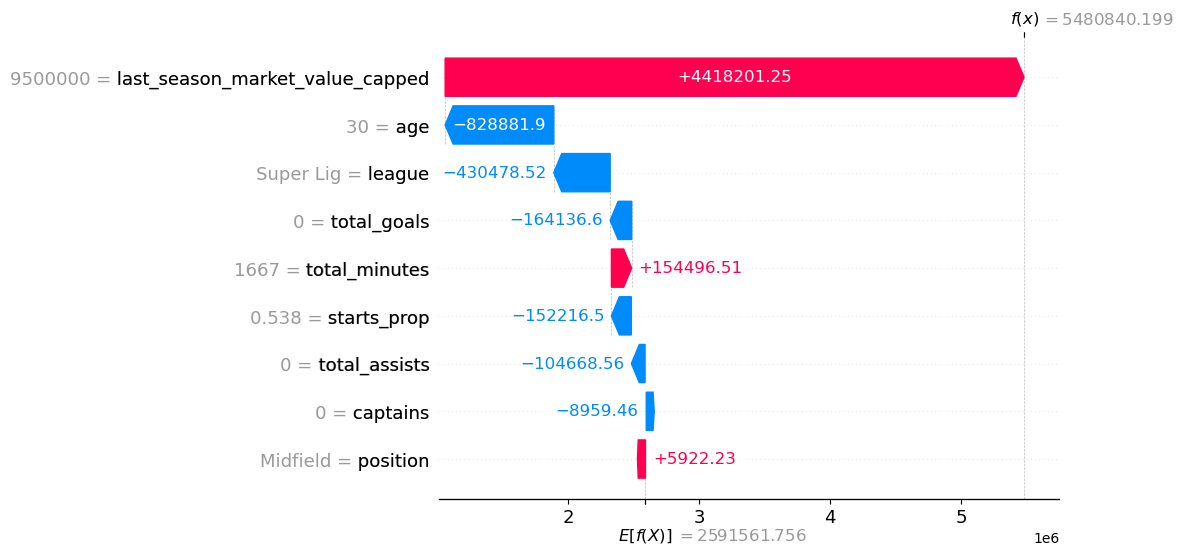

In [20]:
import shap

#Initialize the Explainer
#TreeExplainer is optimized for XGBoost/Tree-based models
explainer = shap.TreeExplainer(catboost_model)

#Calculate SHAP values for the test set
shap_values = explainer(X_test_cat)

#Create a Summary Plot showing the distribution of the impact each feature has on the output
#shap.summary_plot(shap_values, X_test_xgb)

#Waterfall plot for a single prediction
shap.plots.waterfall(shap_values[500])



#### Data Prep for Results Dashboard

In [22]:
#Join predictions to data sets for dashboard building
X_train_cat.loc[:,'pred'] = catboost_model.predict(X_train_cat)
X_test_cat.loc[:,'pred'] = catboost_model.predict(X_test_cat)

X_pred = pd.concat([X_train_cat, X_test_cat], axis = 0)

df_pred_cat = pd.concat([X_pred, y], axis = 1)

tableau_df = pd.concat([final_data_agg, X_pred['pred']], axis=1)

#Save results
tableau_df.to_csv('tableau_df_cat.csv', index=False)